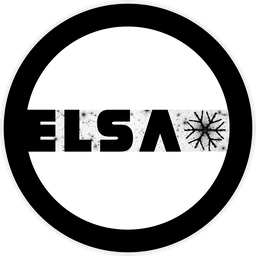

# GELSA tutorial: 1D spectral extraction and decontamination

**[ELSA](https://elsa-euclid.github.io/): Euclid Legacy Science Advanced analysis tools**

**Author(s):** Ben Granett

**Last modified:** 2026-09-28

**Notebook summary:**

Thie notebook demonstrates how to run 1D and 2D spectral extractions with maximum-likelihood decontamination. The data are accessed from the data volumes mounted on ESA Datalabs.

**Useful links:**

* [GELSA notebooks](https://github.com/elsa-euclid/gelsa/gelsa-notebooks/)
* [Documentation](https://elsa-euclid.github.io/gelsa/)
* [Code repository](https://github.com/elsa-euclid/gelsa/)

**Feedback:**

Use the [GELSA issue tracker](https://github.com/elsa-euclid/gelsa/issues) to report bugs or suggest features. Contributions are welcome!

**Acknowledgements:**

If you use GELSA for publications, please include the acknowledgement for the ELSA project below.

"ELSA: Euclid Legacy Science Advanced analysis tools" (Grant Agreement no. 101135203) is funded by the European Union. Views and opinions expressed are however those of the author(s) only and do not necessarily reflect those of the European Union or Innovate UK. Neither the European Union nor the granting authority can be held responsible for them. UK participation is funded through the UK Horizon guarantee scheme under Innovate UK grant 10093177.

**License:**

Copyright 2024–2026 the GELSA contributors. This file is subject to the terms and conditions defined in LICENSE.txt, which forms part of this source code package. No part of the package, including this file, may be copied, modified, propagated, or distributed except according to the terms contained in LICENSE.txt.

<br clear="left">

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm.auto import tqdm

from astroquery.esa.euclid.core import EuclidClass

import gelsa
from gelsa import decontam
from gelsa import decontam_utils
from gelsa import consts
from gelsa import visu
from gelsa.esa import euclid_archive

print(f"Gelsa version {gelsa.version.version}")

Gelsa version 4.0


## 1. Initialize Euclid archive connection and GELSA

In [2]:
# Set your own credentials file for connecting to the Euclid archive.
# The file has username on the first line and password on the second line.
my_credentials_file = '/media/home/my_workspace/password'

Euclid = EuclidClass(environment='IDR')
Euclid.login(credentials_file=my_credentials_file)

INFO: Login to Euclid TAP server: easidr.esac.esa.int:443/tap-server/tap/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid data service: easidr.esac.esa.int:443/sas-dd/tap-server/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid cutout service: easidr.esac.esa.int:443/sas-cutout/tap-server/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]


In [3]:
EA = euclid_archive.EuclidArchive(Euclid)

In [4]:
# initialize the gelsa class
G = gelsa.Gelsa()

## 2. Set a target

Here we define a target based on the `object_id` in the Wide survey. The redshift is also specified, but it is only used below for marking the emission lines in the plots.

- `survey` can be one of (`wide`, `deep`, `deep_visits`, `cosmos`). It is not case-sensitive.
- With `survey=deep_visits`, the `patch_id` is needed to distinguish the visits of the Deep Survey.

In this cell we also set the flux limit `flux_cut_microjy` for modelling contaminant sources.

In [5]:
object_id = 1997078145716314398
redshift = 1.73        # redshift known a priori
ra, dec = euclid_archive.object_id_to_radec(object_id)

survey = 'wide'  # options: `wide`, `deep`, `deep_visits`, `cosmos`
patch_id = None

print("object_id:", object_id)
print("ra, dec:", ra, dec)
print("survey:", survey)
if patch_id:
    print("patch ID:", patch_id)

# decontamination parameters
flux_cut_microjy = 1e6 * 10**(-0.4*(20.5 - 8.9))   # flux limit forcontaminant modeling

object_id: 1997078145716314398
ra, dec: 199.7078145 71.6314398
survey: wide


## 3. Retrieve SIR 1D spectrum

In [6]:
# query can be done by ra, dec...
# sir_pack_list = EA.load_sir_combined_spectrum(ra, dec, patch_id=patch_id, survey=survey)

# ...or object ID
sir_pack_list = EA.load_sir_combined_spectrum(object_id=object_id, patch_id=patch_id, survey=survey)

print(f"got {len(sir_pack_list)} match!")

got 1 match!


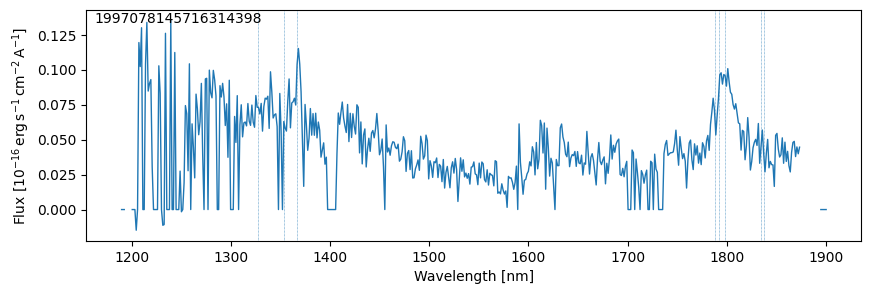

In [7]:
def plot_sir_spectrum(data=None, header=None, maskbits=32+64, lw=1, c=None, **plotparams):
    """ """
    sir_wavelength = data['WAVELENGTH']
    sir_signal = data['SIGNAL']
    sir_mask = data['MASK']
    valid = np.bitwise_and(sir_mask, maskbits) == 0
    sir_signal = np.ma.array(sir_signal, mask=~valid)
    plt.plot(sir_wavelength/10, sir_signal, lw=lw, c=c, **plotparams)
    plt.xlabel("Wavelength [nm]")
    _ = plt.ylabel("Flux [${\\rm 10^{-16}\\,erg\\,s^{-1}\\,cm^{-2}\\,A^{-1}}$]")
    plt.text(0.01, 0.99, header['object_id'], va='top', 
             transform=plt.gca().transAxes)
    
plt.figure(figsize=(10,3))
plot_sir_spectrum(**sir_pack_list[0])
for key, val in consts.line_list.items():
    wave = (1+redshift)*val / 10
    plt.axvline(wave, dashes=[1,1],alpha=0.8, zorder=0, lw=0.5)

## 3. Load catalogs and images for decontamination

In [8]:
decon = decontam.Decontamination()
decon.add_target(ra, dec)

cat = EA.load_mer_catalog(ra, dec, survey=survey, patch_id=patch_id, 
                          radius_deg=0.2)
cat.add_index('OBJECT_ID')
cat.add_index('SEGMENTATION_MAP_ID')

tile_list = np.unique(list(cat['TILE_INDEX']))

sel = cat['FLUX_H_TEMPLFIT'] > flux_cut_microjy
cat = cat[sel]

decon.add_catalog(cat)
print(f"tiles: {tile_list}")
print(f"loaded catalog rows: {len(decon.cat)}")

tiles: [102162070 102162301 102162302]
loaded catalog rows: 10181


In [9]:
for tile_ in tile_list:
    image_, segmap_, wcs_ = EA.load_tile_image(tile_, patch_id)
    decon.add_image(image_, segmap_, wcs_, tile=tile_)
    print(f"loaded tile {tile_}")
print(f"loaded {len(decon.image_list)} tile images")

loaded tile 102162070
loaded tile 102162301
loaded tile 102162302
loaded 3 tile images


## Retrieve the SIR frame file list

This cell submits a query to the Euclid archive for SIR frames that are near to the specified RA, Dec position.

In [10]:
sir_path_list = EA.query_sir_frames(ra, dec, patch_id=patch_id, radius_deg=0.5)

frame_list = []
for path in sir_path_list:
    frame_list.append(G.load_frame(path))

decon.add_frame(*frame_list)


print(f"Found this many SIR frames: {len(decon.frame_list)}")

Found this many SIR frames: 7


### Plot the detector footprints on the sky. 

The target is marked by the star. The frames were selected based the radius search, and so it is not guaranteed that the spectrum of the source
is actually in all the frames. The pixel to sky coordinate mapping is computed at 12200A. This wavelength at the blue side of the red grism corresponds roughly to the position of the galaxy in the direct image.

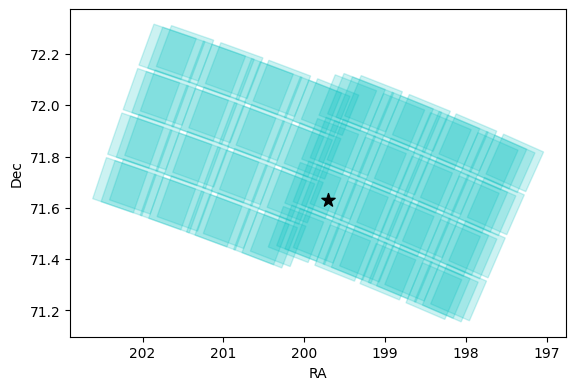

In [11]:
ax = plt.subplot(111, aspect=1./np.cos(np.radians(dec)))
xx = np.array([0, 2040, 2040, 0, 0])
yy = np.array([0, 0, 2040, 2040, 0])
for frame in frame_list:        # loop over frames
    for det in range(16):       # loop over detectors 
        ra_, dec_ = frame.pixel_to_radec(xx, yy, det, wavelength=12200)
        ax.fill(ra_, dec_, alpha=0.2, c='c')
ax.scatter(ra, dec, marker="*", s=100, c='k')
ax.invert_xaxis()
ax.set_xlabel("RA")
_ = ax.set_ylabel("Dec")

## Maximum-likelihood spectral fiting

Now we run the actually fitting procedure that computes the maximum-likelihood solution of the spectral energy distributions of all target and contaminant sources.

`decon.fit` returns a list of fit results, 1 fit for each regularization value passed in `reg_lambda_list`. The fit output has the form `(galaxy_list, fit_info)`, where `galaxy_list` is a list of `galaxy` instances with best-fitting values, and `fit_info` is a dictionary with diagnostic information about the fit.

**Contamination parameters**:
- `wavelength_step`: Spectral resolution in Angstroms for spectral modelling (default 13A). The wavelenght range is set by the transmission window.
- `contaminant_separation_arcsec`: Maximum limit in separation from target for contamination modelling (default 5 arcsec).
- `minimum_separation_arcsec`: Minimum limit in speparation from target for contamination modelling (default 0.3 arcsec).

**Fitting parameters**:
- `smooth`: Use second-derivative regularization operator that enforces smoothness (default True).
- `reg_lambda_list`: list of one or more regularization values to use. The solution will be computed for each value.
- `reg_floor`: The regularization factor that scales the L2 (diagonal) penalty (default 0.001).
- `sigma_clip`: exclude outlier pixels from the fit. This is done iteratively with `masking_iterations`. The pixel values in each raw frame are compared with the best-fitting solution. Values that exceed the threshold value `sigma_clip` are masked (default 10).
- `masking_iterations`: number of iterations for sigma clipping (default 1).
- `nthreads`: number of threads to use.



In [12]:
with tqdm() as progress:
    results = decon.fit(
        reg_lambda_list=[500,],
        sigma_clip=5,
        nthreads=4,
        progress_hook=progress.update
    )

0it [00:00, ?it/s]

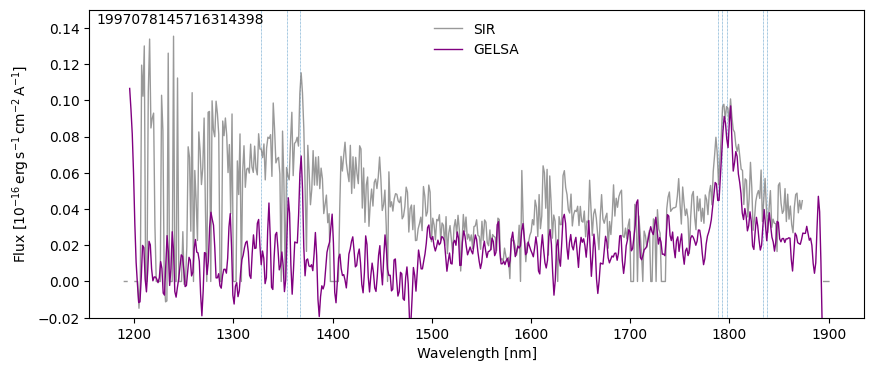

In [13]:
# The first result corresponds to the first regularization value from `reg_lambda_list`.
# fit_info contains fit diagnostics
best_fit_galaxies, fit_info = results[0]

# Plot the first galaxy in the list. This is the target.
gal_ = best_fit_galaxies[0]

plt.figure(figsize=(10,4))
plot_sir_spectrum(**sir_pack_list[0], c='grey', alpha=0.8, label='SIR')
plt.plot(gal_.wavelength/10, gal_.sed_params*1e16, lw=1, c='purple', zorder=10, label='GELSA')
plt.legend(frameon=False)
plt.ylim(-0.02,0.15)


for key, val in consts.line_list.items():
    wave = (1+redshift)*val / 10
    plt.axvline(wave, dashes=[1,1],alpha=0.8, zorder=0, lw=0.5)

## Gallery of targets and contaminants

Here we are plotting the stamps of the target and contmainant sources that were used in the decontamintion modelling.
Note that the IDs printed below are the MER segmentation map IDs, not the object_id!


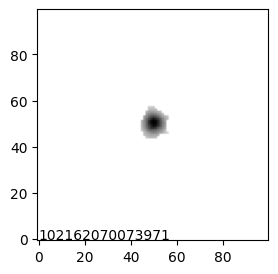

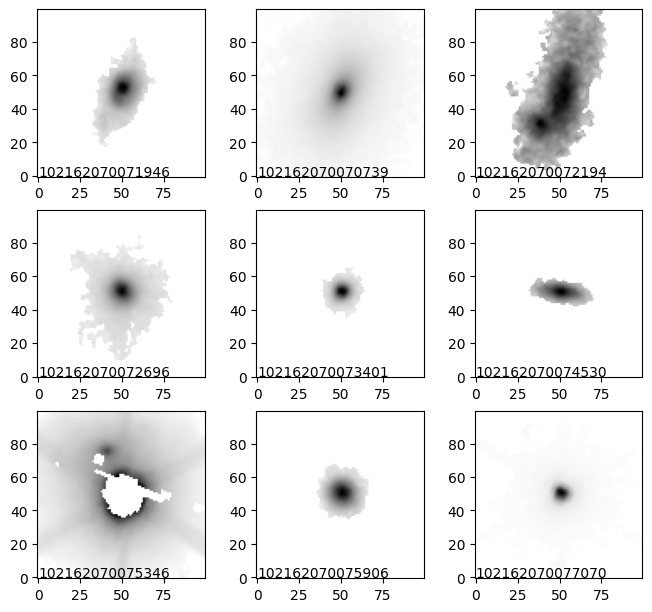

In [14]:
plt.figure(figsize=(3, 3))
plt.imshow(visu.normalize_image(decon.targets[0]._stamp, levels=(10,99.99)), 
           origin='lower', cmap='binary')
plt.text(0,0,decon.targets[0].params['object_id'])

plt.figure(figsize=(8, 10))
n = len(decon.contaminants)
nrow = 3
ncol = n // nrow + 1
for i, gal in enumerate(decon.contaminants):
    plt.subplot(ncol, nrow, i+1)
    plt.imshow(visu.normalize_image(gal._stamp, levels=(10,99.99)), 
               origin='lower', cmap='binary')
    plt.text(0,0,gal.params['object_id'])


## Visualize best-fitting model

The following plots show the data, model and residual (data-model) for the target source in the original pixel-space of the NISP frame.

Each panel shows the pixels of the target galaxy that were used in the fit. The pixels of the contaminant galaxies are not shown here.

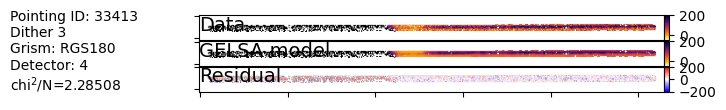

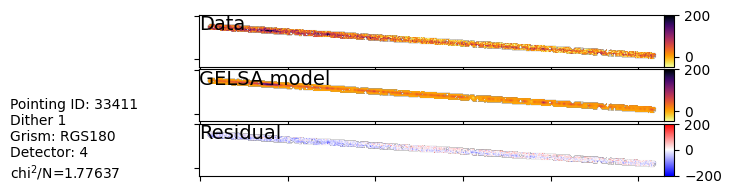

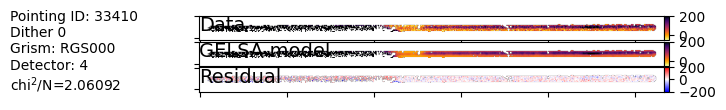

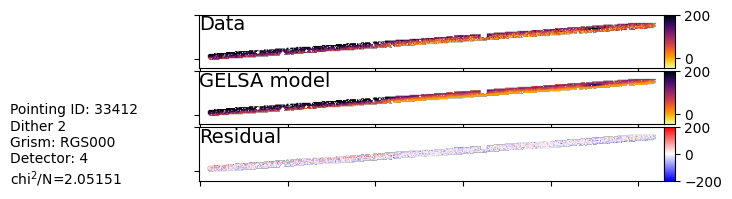

In [15]:
for pack in results:
    decontam_utils.plot2d_target(fit_info, decon.specimager_list, vmax=200)

These next plots show both the target and the contaminants that were used in the fit.

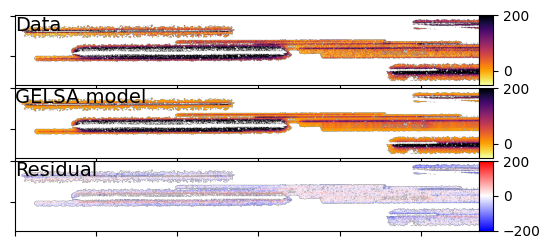

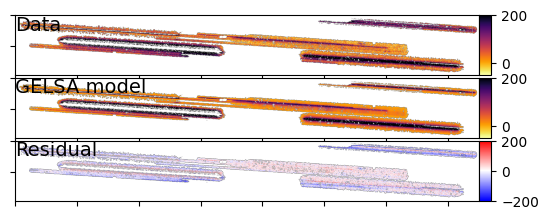

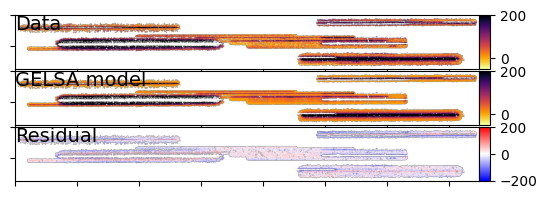

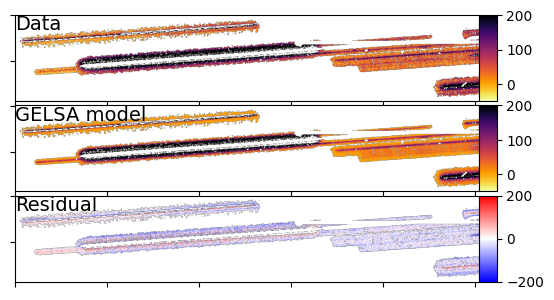

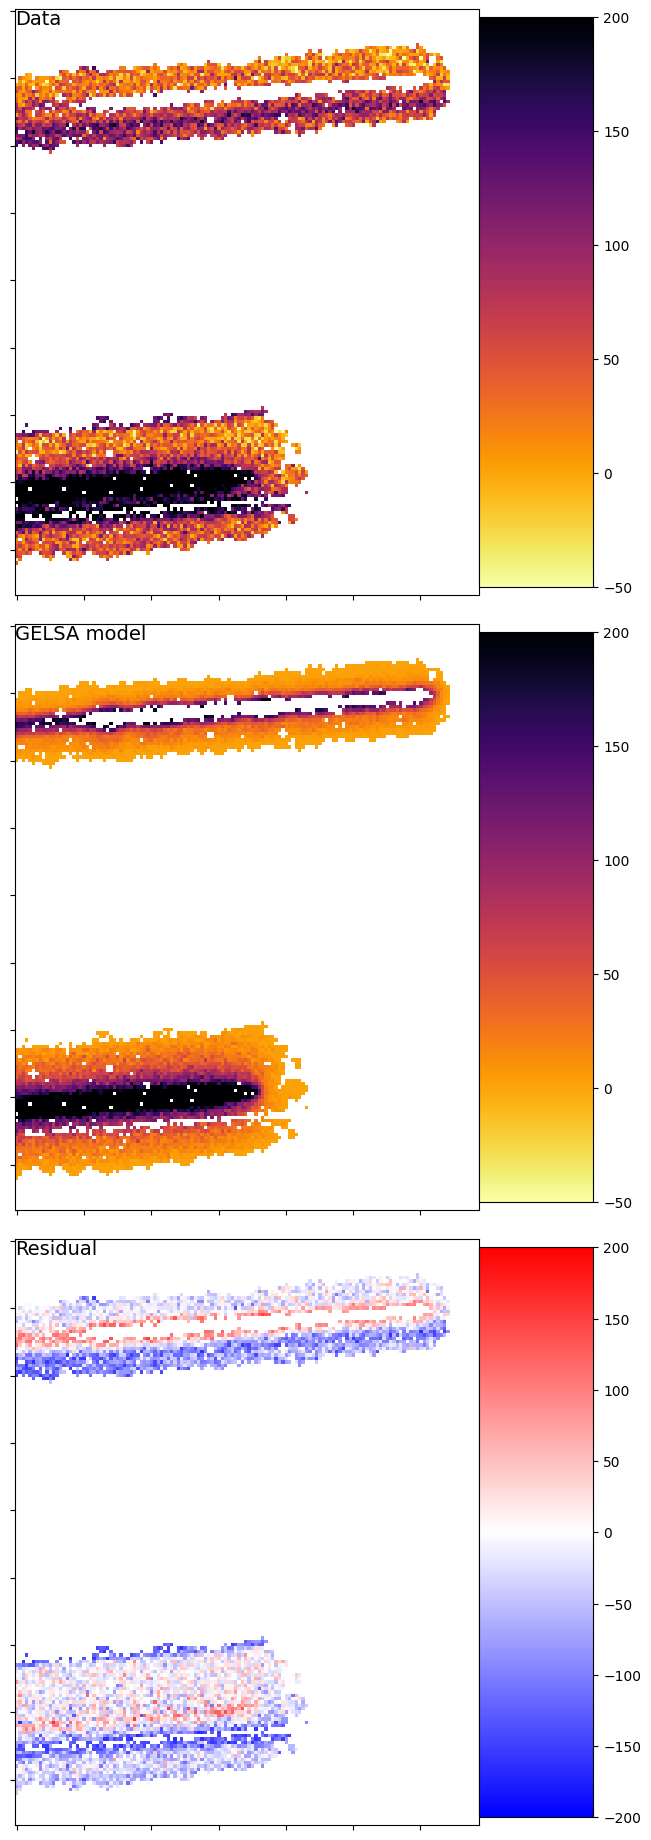

In [16]:
for pack in results:
    decontam_utils.plot2d(fit_info, vmax=200)